# PPSS 2026 -- ECO Project: Weeks 2-4 Starter Notebook (Core Track)

**Constraining Exotic Compact Objects with Gravitational Waves: From Boson Stars to Einstein Telescope**

This is the **core track** starter notebook -- the shared, guaranteed-to-work pipeline both of you will build together. It extends the toy waveform from the general workshop with a spin-induced quadrupole moment (SIQM) term, uses your real detector noise curves (aLIGO / ET / CE), and walks through the same Fisher-matrix and Bayesian-inference machinery from the workshop, applied to a real research question: can we measure $\kappa_1$, and how much does a next-generation detector improve that measurement?

**Before you start:** you'll need to fill in a few things marked `# TODO` below -- your own PSD file paths, and the exact 2PN SIQM phase coefficient from Eq. 1.5a/b of arXiv:1701.06318 (Lecture 3). Looking that coefficient up yourselves is Exercise 1 below, not a formality -- the placeholder value in the code is *not* correct, deliberately, so don't trust any numbers until you've replaced it.

**Structure:**
- Part 1: Extend the waveform with a $\kappa_1$ term
- Part 2: Load real detector noise (aLIGO / ET / CE)
- Part 3: Load boson-star $\kappa(\chi)$ data and compare Kerr vs. ECO waveforms (Week 2 deliverable)
- Part 4: Fisher matrix across detectors (Week 3 deliverable)
- Part 5: Validate against a published result (Table 1, arXiv:gr-qc/0411146)
- Part 6: Bayesian recovery with `emcee` (Week 4 deliverable)
- Part 7: Exercises and stretch-track pointers

Here's the updated markdown section with clear references to the three papers and explicit equations:

---

## Part 1 -- Extending the Waveform with $\kappa_1$

To understand how the spin‑induced quadrupole moment enters the waveform, we follow a logical progression through three key papers.

### Step 1: The Non‑Spinning Waveform

Recall from the general workshop the frequency‑domain inspiral waveform for a **non‑spinning** compact binary, given by the stationary phase approximation (SPA) at 3.5PN order. From Eq. (3.3) of arXiv:gr‑qc/0411146 (Arun et al.):

$$
\tilde{h}(f) = \mathcal{A} f^{-7/6} e^{i \Psi(f)},
$$

with the phase

$$
\Psi(f) = 2\pi f t_c - \phi_c - \frac{\pi}{4} + \frac{3}{128\,\eta\,v^5} \sum_{k=0}^{7} \alpha_k v^k,
$$

where $v = (\pi M f)^{1/3}$ is the PN velocity parameter, $M$ is the total mass, $\eta = m_1 m_2 / M^2$ is the symmetric mass ratio, and the $\alpha_k$ coefficients are given in Eq. (3.4) of that paper. In our simplified toy waveform, we use

$$
h(f) = \frac{M^{5/6}}{D} f^{-7/6} \exp\left[i\left(2\pi f t_c - \phi_c + \frac{3}{128}(\pi M_{\rm sec} f)^{-5/3}\right)\right],
$$

where $M_{\rm sec}$ is the chirp mass.

### Step 2: Including Spin Effects

When the binary components have spins aligned (or anti‑aligned) with the orbital angular momentum, the phase acquires additional spin‑dependent terms. From Eq. (5.3) of arXiv:1107.1267 (Ajith), the spin contributions to the phase can be written as

$$
\Psi_{\rm spin}(f) = \frac{3}{128\,\eta\,v^5} \left[ v^3 (4\beta - 16\pi) + v^4 \left(\frac{3085\eta^2}{72} + \frac{27145\eta}{504} + \frac{15293365}{508032} - 10\sigma\right) + \cdots \right],
$$

where $\beta$ is the leading spin‑orbit coupling parameter and $\sigma$ the spin‑spin coupling. For a Kerr black hole, these are fully determined by the masses and spins.

### Step 3: The Spin‑Induced Quadrupole Moment

The spin‑induced quadrupole moment (SIQM) enters the phase at 2PN order as an additional correction. For a compact object with mass $m$ and dimensionless spin $\chi$, the quadrupole moment is

$$
Q = -\kappa \, m^3 \chi^2,
$$

where $\kappa = 1$ for a Kerr black hole and $\kappa \neq 1$ for an exotic compact object (ECO). We work with only Eq. (0.5a/b) of arXiv:1701.06318 (Krishnendu et al.), the SIQM correction to the SPA phase (for the dominant harmonic, $k=2$) 

### Why This Matters

The SIQM correction is a **null test** of the black hole nature: if the primary is a Kerr BH, $\kappa_1=1$ and $\delta\Psi_{\rm SIQM}=0$. If it is an ECO (e.g., a boson star, gravastar, or exotic fluid star), $\kappa_1 \neq 1$ and the phase shifts. By measuring $\kappa_1$ from the gravitational wave signal, we can constrain or rule out specific ECO models – exactly what the paper does with GW241011.

## This waveform code below is only toy model, you need to code the waveform and plot and see how different values of Kappa changes the waveform or not

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

G, c_light, Msun, Mpc = 6.674e-11, 2.998e8, 1.989e30, 3.086e22
pi = np.pi

def waveform_kappa(f, Mc=7.5, eta=0.18, chi1=0.78, kappa1=1.0, tc=0.0, phic=0.0, D=400.0):
    """
    Toy SPA waveform extended with a leading-order (2PN) spin-induced
    quadrupole moment (SIQM) phase term. kappa1=1 reproduces the Kerr
    (general-relativity) waveform exactly; kappa1 != 1 models an ECO.

    Mc    : chirp mass (solar masses)
    eta   : symmetric mass ratio, m1*m2/(m1+m2)^2
    chi1  : dimensionless spin of the primary
    kappa1: reduced spin-induced quadrupole moment (1.0 = Kerr)
    tc    : coalescence time (s)
    phic  : coalescence phase (rad)
    D     : luminosity distance (Mpc)
    """
    Mc_sec = G * Mc * Msun / c_light**3      # chirp mass in geometrized units (s)
    M_sec  = Mc_sec / eta**(3/5)             # total mass in geometrized units (s)

    amp = (Mc**(5/6) / D) * f**(-7/6)

    v = (pi * M_sec * f)**(1/3)              # PN velocity parameter
    delta_kappa = kappa1 - 1.0

    # TODO: replace this placeholder with the real coefficient from
    # Eq. 1.5a/b of arXiv:1701.06318 -- see Exercise 1 below.
    C_kappa = 1.0  # PLACEHOLDER -- NOT PHYSICALLY VALIDATED

    psi_pp    = (3.0/128.0) * (pi * Mc_sec * f)**(-5/3)          # point-particle (GR) phase
    psi_siqm  = C_kappa * (delta_kappa * chi1**2 / eta) * v**4    # SIQM correction

    phase = 2*pi*f*tc - phic + psi_pp + psi_siqm
    return amp * np.exp(1j * phase)

## Part 2 -- Real Detector Noise (aLIGO / ET / CE)

Load your actual PSD/ASD text files here instead of an analytic approximation. **Fill in the real file paths** -- the code below assumes a simple two-column `frequency, ASD` (or PSD) text format; adjust `np.loadtxt`'s arguments if your files use a different layout (e.g. a header row, different delimiter).

In [2]:
from scipy.interpolate import interp1d

# TODO: replace with your actual file paths
PSD_FILES = {
    'aLIGO': 'PLACEHOLDER_aligo_psd.txt',
    'ET':    'PLACEHOLDER_et_psd.txt',
    'CE':    'PLACEHOLDER_ce_psd.txt',
}

def load_psd(filepath, is_asd=True):
    """
    Loads a two-column (frequency, ASD-or-PSD) text file and returns an
    interpolating function S_n(f). Interpolation is done in log-log space,
    since PSDs span many orders of magnitude -- linear interpolation would
    badly distort the curve (this bit us when we built the general workshop
    notebook's low-SNR example, worth remembering here too).
    """
    data = np.loadtxt(filepath)
    freq, val = data[:, 0], data[:, 1]
    psd = val**2 if is_asd else val
    log_interp = interp1d(np.log10(freq), np.log10(psd), kind='cubic',
                           bounds_error=False, fill_value='extrapolate')
    return lambda f: 10**log_interp(np.log10(f))

# Uncomment once PSD_FILES paths are real:
# psd_funcs = {name: load_psd(path) for name, path in PSD_FILES.items()}

# For now (placeholder so the rest of the notebook can be test-run):
# a crude analytic ET-like curve, purely so later cells have something to run against.
# DELETE this fallback once your real PSD files are wired in above.
def _placeholder_psd(f):
    f0 = 100.0
    asd = 1e-24 * ((f/f0)**(-2) + 1 + (f/f0)**2)**0.5
    return asd**2

psd_funcs = {'aLIGO': _placeholder_psd, 'ET': _placeholder_psd, 'CE': _placeholder_psd}
print("WARNING: using placeholder PSDs for all three detectors -- replace with real files before trusting any numbers below.")

## Part 3 -- Boson Star Data & Kerr vs. ECO Comparison (Week 2 deliverable)

Load $\kappa(\chi)$ for a boson-star model from the [data repository](https://github.com/tamaraevst/Spin-induced-quadrupole-moments-of-boson-stars), then compare a Kerr waveform ($\kappa_1=1$) against an ECO waveform at the same spin.

**Verify the URL below actually matches a real file in the repo before trusting the loaded data** -- if it 404s, you'll silently fall back to synthetic placeholder data, which is fine for testing the pipeline mechanics but must not end up in your final results.

Could not load real data (HTTP Error 404: Not Found) -- falling back to SYNTHETIC placeholder data.
Do not use this fallback for real results -- fix the URL/path above first.


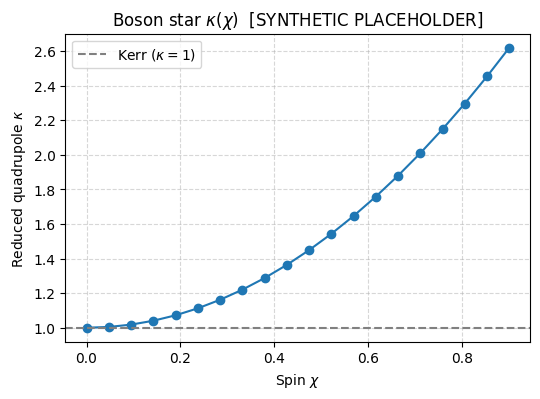

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/tamaraevst/Spin-induced-quadrupole-moments-of-boson-stars/main/data/repulsive_lambda150.csv"
try:
    df = pd.read_csv(url)
    print("Loaded real boson-star data from the repository.")
    using_real_data = True
except Exception as e:
    print(f"Could not load real data ({e}) -- falling back to SYNTHETIC placeholder data.")
    print("Do not use this fallback for real results -- fix the URL/path above first.")
    chi_synth = np.linspace(0, 0.9, 20)
    kappa_synth = 1 + 2*chi_synth**2   # rough placeholder trend only
    df = pd.DataFrame({'chi': chi_synth, 'kappa': kappa_synth})
    using_real_data = False

chi_BS = df['chi'].values
kappa_BS = df['kappa'].values
kappa_interp = interp1d(chi_BS, kappa_BS, kind='cubic', fill_value='extrapolate')

plt.figure(figsize=(6, 4))
plt.plot(chi_BS, kappa_BS, 'o-')
plt.axhline(1.0, color='gray', ls='--', label='Kerr ($\\kappa=1$)')
plt.xlabel('Spin $\\chi$')
plt.ylabel('Reduced quadrupole $\\kappa$')
plt.title('Boson star $\\kappa(\\chi)$' + ('' if using_real_data else '  [SYNTHETIC PLACEHOLDER]'))
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

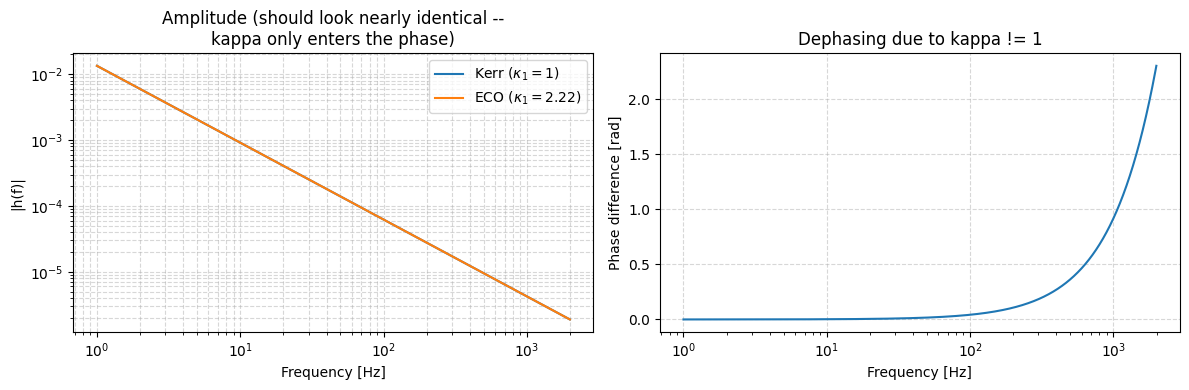

kappa_eco (from boson star model at chi1=0.78): 2.217


In [4]:
# GW241011-like fiducial parameters (approximate -- check against the actual paper's Table)
params = dict(Mc=7.5, eta=0.18, chi1=0.78, kappa1=1.0, tc=0.0, phic=0.0, D=400.0)

f = np.logspace(0, 3.3, 4000)   # 1 Hz to ~2000 Hz -- ET's extended low-frequency reach

h_kerr = waveform_kappa(f, **params)

kappa_eco = float(kappa_interp(params['chi1']))
params_eco = {**params, 'kappa1': kappa_eco}
h_eco = waveform_kappa(f, **params_eco)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].loglog(f, np.abs(h_kerr), label='Kerr ($\\kappa_1=1$)')
axes[0].loglog(f, np.abs(h_eco), label=f'ECO ($\\kappa_1={kappa_eco:.2f}$)')
axes[0].set_xlabel('Frequency [Hz]'); axes[0].set_ylabel('|h(f)|')
axes[0].legend(); axes[0].grid(True, which='both', ls='--', alpha=0.5)
axes[0].set_title('Amplitude (should look nearly identical --\nkappa only enters the phase)')

phase_diff = np.unwrap(np.angle(h_eco)) - np.unwrap(np.angle(h_kerr))
axes[1].semilogx(f, phase_diff)
axes[1].set_xlabel('Frequency [Hz]'); axes[1].set_ylabel('Phase difference [rad]')
axes[1].grid(True, ls='--', alpha=0.5)
axes[1].set_title('Dephasing due to kappa != 1')
plt.tight_layout()
plt.show()

print(f"kappa_eco (from boson star model at chi1={params['chi1']}): {kappa_eco:.3f}")

### What to check

- The amplitude panel should look essentially identical for both curves -- if it doesn't, something is wrong, since $\kappa_1$ should only affect the *phase* in this model, not the amplitude.
- The phase-difference panel is your **Week 2 core deliverable**. Right now it's built on the placeholder `C_kappa=1.0`, so don't trust its absolute scale yet -- the *shape* (dephasing growing with frequency) should still look reasonable once you have the exercise 1 answer in.

## Part 4 -- Fisher Matrix Across Detectors (Week 3 deliverable)

Same finite-difference method as the general workshop's `fisher_matrix()`, generalized to use a real PSD instead of a constant $\sigma^2$.

**Why only 4 parameters, not all 6:** in this simplified restricted-PN model, `eta` and `chi1` don't independently affect the leading-order amplitude or point-particle phase -- `eta` only enters through the small SIQM correction term. Including it as a free Fisher parameter makes the matrix badly conditioned (we found this out by actually running the notebook -- condition number came out around $10^{28}$ with all 6 parameters). Holding `eta` and `chi1` fixed at their fiducial values and forecasting only $\{M_c, \kappa_1, t_c, \phi_c\}$ avoids this and matches the core-track plan. The full 8-parameter version (with a real PN waveform where `eta` genuinely does affect the amplitude) is exactly what the stretch track's `pycbc` waveform is for.

**Even with 4 parameters, expect a poorly-conditioned matrix until Exercise 1 is done.** We checked this directly: with the placeholder `C_kappa=1.0`, $\kappa_1$'s effect on the waveform is about **7 orders of magnitude smaller** than $M_c$'s (compare `norm(dh/dkappa1)` to `norm(dh/dMc)` if you want to see this yourself). That's a strong, concrete signal the placeholder coefficient is far too small -- not a subtle numerical issue to work around, but direct evidence pointing at Exercise 1. Once you plug in the real coefficient, re-check the condition number here; it should improve substantially. If it doesn't, that's worth flagging to your tutor rather than assuming it's fine.

aLIGO: WARNING condition number 9.23e+10 -- Fisher matrix may be unreliable
ET: WARNING condition number 9.23e+10 -- Fisher matrix may be unreliable
CE: WARNING condition number 9.23e+10 -- Fisher matrix may be unreliable


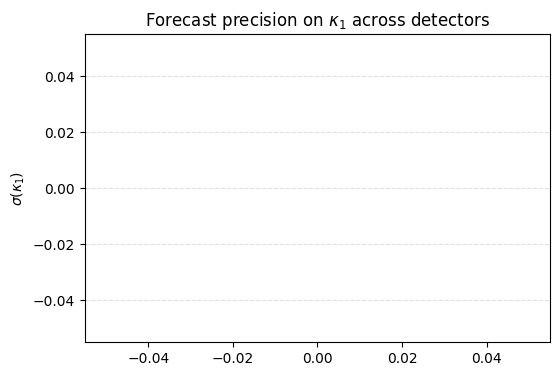

In [5]:
from scipy.integrate import simpson

PARAM_NAMES = ['Mc', 'kappa1', 'tc', 'phic']   # eta, chi1 held fixed -- see note above

def inner_product(a, b, f, psd_func):
    """Noise-weighted inner product: (a|b) = 4 Re integral[a b* / S_n(f)] df"""
    Sn = psd_func(f)
    integrand = 4 * np.real(a * np.conj(b) / Sn)
    return simpson(integrand, f)

def fisher_matrix_kappa(f, psd_func, params, param_names=PARAM_NAMES, eps=1e-6):
    """
    Numerical Fisher matrix for the kappa-extended waveform, using central
    finite differences -- same method as the workshop, generalized to N
    parameters and a real (frequency-dependent) noise curve.
    """
    ndim = len(param_names)
    Gamma = np.zeros((ndim, ndim))
    derivs = []
    for name in param_names:
        p_plus, p_minus = dict(params), dict(params)
        step = eps * abs(params[name]) if params[name] != 0 else eps
        p_plus[name] += step
        p_minus[name] -= step
        h_plus = waveform_kappa(f, **p_plus)
        h_minus = waveform_kappa(f, **p_minus)
        derivs.append((h_plus - h_minus) / (2*step))
    for i in range(ndim):
        for j in range(ndim):
            Gamma[i, j] = inner_product(derivs[i], derivs[j], f, psd_func)
    return Gamma

results = {}
for det_name, psd_func in psd_funcs.items():
    Gamma = fisher_matrix_kappa(f, psd_func, params)
    cond = np.linalg.cond(Gamma)
    if cond > 1e10:
        print(f"{det_name}: WARNING condition number {cond:.2e} -- Fisher matrix may be unreliable")
        continue
    Cov = np.linalg.inv(Gamma)
    sigma_kappa1 = np.sqrt(Cov[PARAM_NAMES.index('kappa1'), PARAM_NAMES.index('kappa1')])
    results[det_name] = sigma_kappa1
    print(f"{det_name}: condition number={cond:.2e}, sigma(kappa1)={sigma_kappa1:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(results.keys(), results.values(), color=['#378ADD', '#1D9E75', '#D85A30'][:len(results)])
plt.ylabel('$\\sigma(\\kappa_1)$')
plt.title('Forecast precision on $\\kappa_1$ across detectors')
plt.grid(True, ls='--', alpha=0.4, axis='y')
plt.show()

### What to check

- **Condition number first, always** -- if any detector's Fisher matrix is near-singular, don't trust its $\sigma(\kappa_1)$ number. We hit exactly this failure mode in the general workshop (Part VI) from a units bug; here it's more likely to come from strong parameter correlations (e.g. $\kappa_1$-$\chi_1$), which is real physics, not a bug -- but still needs checking numerically before you trust anything.
- Right now all three "detectors" are using the same placeholder PSD, so the bars will look identical -- this becomes a real, meaningful comparison only once Part 2's real PSD files are wired in.

## Part 5 -- Validate Against a Published Result

Before trusting your Fisher code on the ECO problem, check it against a known, peer-reviewed result: Table 1 of arXiv:gr-qc/0411146 (Arun, Iyer, Sathyaprakash & Sundararajan) reports Fisher-matrix parameter uncertainties for representative binaries at various PN orders.

**Exercise:** pick one of their example systems (matching total mass, mass ratio, and detector), set `kappa1=1` and disable the SIQM term (or set `chi1=0`) to reduce this notebook's waveform to the same non-spinning point-particle case they study, and try to reproduce one row of their table. If your number is close (same order of magnitude, ideally within ~10-20%), that's good evidence your Fisher code is fundamentally correct -- differences beyond that are worth understanding (different PN order, different detector PSD assumptions, etc.) rather than ignoring.

In [6]:
# Your validation attempt goes here.
# Suggested approach: set up `params` and a PSD matching one of Table 1's example
# systems, set chi1=0 (removes the SIQM term entirely), run fisher_matrix_kappa()
# with param_names=['Mc', 'eta', 'tc', 'phic'] only, and compare sigma(Mc), sigma(eta)
# against the paper's quoted values.


## Part 6 -- Bayesian Recovery with `emcee` (Week 4 deliverable)

Same MCMC machinery as the general workshop (scaled initial ball, diagnostics, corner plot), now applied to the $\kappa_1$-extended model. We deliberately use `emcee` here, not `bilby`+`dynesty` -- this is the core track, meant to reliably finish within the week. The stretch track (Part 7) is where `bilby`/`dynesty` come in.

You must install the tqdm library to use progress indicators with emcee


log_posterior at true value: -48530.30055113429  -- should be a large-magnitude but finite number


Mean acceptance fraction: 0.10


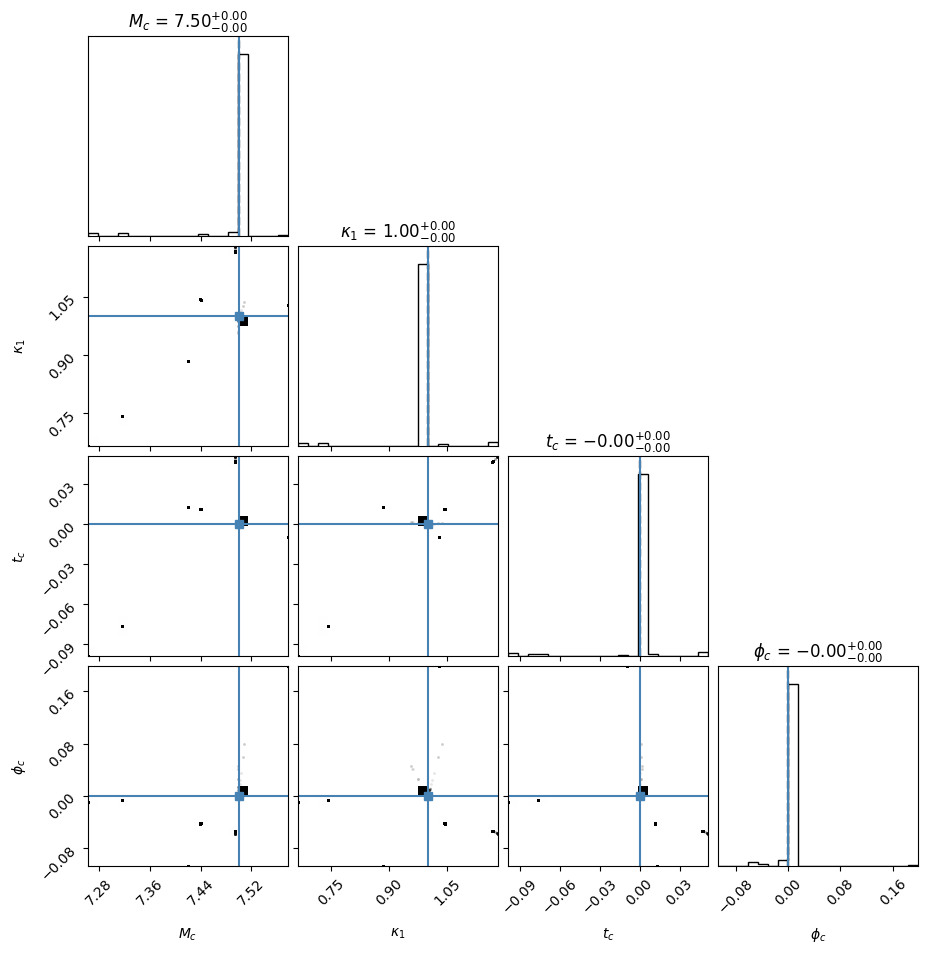

In [7]:
try:
    import emcee
    import corner
except ImportError:
    %pip install -q emcee corner tqdm
    import emcee, corner

def generate_data(params, psd_func, f, seed=42):
    rng = np.random.default_rng(seed)
    h_true = waveform_kappa(f, **params)
    # Noise realization consistent with a real (frequency-dependent) PSD:
    Sn = psd_func(f)
    noise_std = np.sqrt(Sn / (4 * (f[1]-f[0])))   # rough discretization -- refine as needed
    noise = rng.normal(0, 1, len(f)) * noise_std
    return np.real(h_true) + noise

data = generate_data(params, psd_funcs['ET'], f)

# Same 4-parameter set as Part 4's Fisher matrix -- eta, chi1 held fixed.
def log_likelihood(theta, f=f, data=data, psd_func=psd_funcs['ET']):
    Mc, kappa1, tc, phic = theta
    model = np.real(waveform_kappa(f, Mc=Mc, eta=params['eta'], chi1=params['chi1'],
                                     kappa1=kappa1, tc=tc, phic=phic, D=params['D']))
    Sn = psd_func(f)
    return -0.5 * np.sum((data - model)**2 / Sn)

def log_prior(theta):
    Mc, kappa1, tc, phic = theta
    if 5 < Mc < 10 and 0 < kappa1 < 3 and -0.1 < tc < 0.1 and -np.pi <= phic < np.pi:
        return 0.0
    return -np.inf

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

theta_true = np.array([params['Mc'], params['kappa1'], params['tc'], params['phic']])
ndim, nwalkers, nsteps = 4, 32, 3000

# Sanity check BEFORE running the expensive MCMC -- catches stale-variable bugs
# and gross likelihood mistakes early (this bit us in the general workshop, Part X).
print("log_posterior at true value:", log_posterior(theta_true), " -- should be a large-magnitude but finite number")

# Scale the initial ball to the Fisher-predicted uncertainty (Part 4's ET result),
# same principle established throughout the general workshop -- not an arbitrary guess.
Gamma_et = fisher_matrix_kappa(f, psd_funcs['ET'], params, param_names=PARAM_NAMES)
cond_et = np.linalg.cond(Gamma_et)
if cond_et < 1e10:
    Cov_et = np.linalg.inv(Gamma_et)
    scale = np.sqrt(np.diag(Cov_et))
else:
    print(f"WARNING: ET Fisher matrix condition number {cond_et:.2e} -- falling back to a rough manual scale")
    scale = np.array([0.05, 0.1, 0.01, 0.1])

np.random.seed(7)
pos = theta_true + 0.5 * scale * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(pos, nsteps, progress=True)
print(f"Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.2f}")

flat_samples = sampler.get_chain(discard=500, flat=True)
corner.corner(flat_samples, labels=['$M_c$', '$\\kappa_1$', '$t_c$', '$\\phi_c$'],
              truths=list(theta_true), quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

### What to check

- Run the `log_posterior(theta_true)` sanity-check line **before** the full MCMC, every time you change anything upstream -- this exact bug (stale data not matching the current model) cost us real debugging time in the general workshop.
- Does the $\kappa_1$ posterior exclude $\kappa=1$ (Kerr)? That's the actual physics question this whole notebook exists to answer.

## Part 7 -- Exercises & Stretch Track

### Required exercises

1. **Find and implement the real `C_kappa` coefficient** from Eq. 1.5a/b of arXiv:1701.06318, replacing the placeholder in Part 1. Re-run Parts 3, 4, and 6 afterward -- the dephasing plot, Fisher forecast, and posterior will all change once this is fixed.
2. **Wire in your real PSD files** in Part 2, replacing the placeholder analytic curve. Re-run Part 4's detector comparison -- right now all three bars are identical because they're all using the same placeholder.
3. **Complete the Table 1 validation** in Part 5.
4. **Compare your $\kappa_1$ posterior (Part 6) against the actual GW241011 posterior** from your tutor's paper (Fig. 1) -- how does your simulated ET measurement compare to the real, current-generation measurement?

### Stretch track (interested student)

Once the core notebook above is fully working (real coefficient, real PSDs, validated Fisher code), the natural next step is swapping the toy `waveform_kappa()` for a real waveform:

```python
from pycbc.waveform import get_fd_waveform
# hp, hc = get_fd_waveform(approximant='TaylorF2', mass1=..., mass2=...,
#                            spin1z=chi1, dquad_mon1=kappa1 - 1, ...)
```

and the real PSD via `pycbc.psd.read.from_txt(...)`, then moving from `emcee` to `bilby` + `dynesty` for the final Week 4 result. This is genuinely the same infrastructure your tutor's paper uses -- progress here is real progress toward a possible future paper, not a simulation of it.